# Exploratory Data Analysis

In [3]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import duckdb
from collections import Counter
import json

## Initializing DuckDB

In [4]:
con = duckdb.connect(database=':memory:')

In [5]:
DATADIR = '../datasets/cloud_energy_consumption/'
NODE_GROUPS = os.path.join(DATADIR, 'node-groups/2024-12-14T000000Z_2025-04-13T235959Z/groups.csv')
VM_HARDWARE = os.path.join(DATADIR, 'vms/2024-12-14T000000Z_2025-04-13T235959Z/vms.csv')

con.query(f"""CREATE OR REPLACE TABLE nodegroups AS SELECT * FROM '{NODE_GROUPS}'""")
con.query(f"""CREATE OR REPLACE TABLE vmhardware AS SELECT * FROM '{VM_HARDWARE}'""")

## Node-Groups
Contains the hardware characteristics and information about the physical nodes in the IFCA Cloud infrastructure.

The `node_group` of the physical nodes is equivalent to the `hypervisor_group` of the virtual machines running in them. 

In [9]:
con.query(""" SELECT * FROM nodegroups""").show()

┌────────────┬──────────────────────────────────┬────────────────┬──────────┬──────────────────────────────────────────────┬───────────────────┬───────────────────┬─────────────┬─────────────────────────────┬───────────────────┬──────────────────────┬───────┬─────────────────────────────┬────────────────┬───────────────────────────────────────────────┬──────────────────┬──────────────────────────────────────┬────────┬─────────────┬───────────────────────────────────────┬──────────────┬──────────────┬──────────────────┬─────────────────┬─────────────────┐
│ node_group │              model               │  form_factor   │ #sockets │                     cpu                      │ #cores_per_socket │ #threads_per_core │ memory_type │     memory_manufacturer     │ memory_used_slots │ memory_total_size_GB │ #gpus │         #gpu_model          │ #ethernet_nics │              ethernet_nic_model               │ #infiniband_nics │         infiniband_nic_model         │ #disks │ disk_vendor │    

#### Which Columns to keep (or not to keep)

The following columns won't add any information for the analysis
- Disk: Disk_model, Disk_type, disk_vendor
- Infiniband: infiniband_nic_model
- Ethernet: ethernet_nic_model
- GPU: gpu_model
- Memory: memory_manufacturer, memory_type
- model, cpu

In [4]:
columns_to_drop = ["model", "cpu", "memory_manufacturer",
                   "memory_type", "gpu_model", "ethernet_nic_model",
                   "infiniband_nic_model", "disk_model", "disk_type", "disk_vendor"]
for col in columns_to_drop:
    con.query(f"ALTER TABLE nodegroups DROP COLUMN IF EXISTS {col}")

con.query("""DESCRIBE nodegroups""").show()

┌──────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │ column_type │  null   │   key   │ default │  extra  │
│       varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ node_group           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ form_factor          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ #sockets             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ #cores_per_socket    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ #threads_per_core    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ memory_used_slots    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ memory_total_size_GB │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ #gpus                │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ #gpu_model           │ VARCHAR     │ YES     │ NUL

#### Missing Values
No NULL values present 

In [14]:
cols = con.query("DESCRIBE nodegroups").df()["column_name"].tolist()

union_query = " UNION ALL ".join(
    f"SELECT '{c}' AS column_name, COUNT(*) - COUNT(\"{c}\") AS null_count FROM nodegroups"
    for c in cols
)
con.query(union_query).show()

┌──────────────────────┬────────────┐
│     column_name      │ null_count │
│       varchar        │   int64    │
├──────────────────────┼────────────┤
│ node_group           │          0 │
│ form_factor          │          0 │
│ #sockets             │          0 │
│ #cores_per_socket    │          0 │
│ #threads_per_core    │          0 │
│ memory_used_slots    │          0 │
│ memory_total_size_GB │          0 │
│ #gpus                │          0 │
│ #gpu_model           │          0 │
│ #ethernet_nics       │          0 │
│ #infiniband_nics     │          0 │
│ #disks               │          0 │
│ disk_size_GB         │          0 │
│ #fans                │          0 │
│ #power_supplies      │          0 │
│ rated_power          │          0 │
└──────────────────────┴────────────┘
  16 rows                 2 columns



#### Dataset shape
6 rows and 16 columsn

In [15]:
con.query("""SELECT COUNT(*) FROM nodegroups""").show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│            6 │
└──────────────┘



## VM Hardware 
Hardware characteristics and information about the virtual machines in the IFCA Cloud infrastructure, including their user and project information.

The `vm_id` of the virtual machines in this dataset is equivalent to the `vm_id` of the virtual machines in the "Virtual Machines energy consumption metrics" dataset. The `project_id` and `user_id` of the virtual machines in this dataset are used to identify the project and user associated with them.

**Shape**: (611, 8)

**Identifiers:**
- `vm_id`: The ID of the virtual machine. (STRING)
- `project_id`: The ID of the project. (STRING)
- `user_id`: The ID of the user. A user can belong to multiple projects. (STRING)
    
**Virtual Machines Characteristics:**
- `image_ref`: The ID of the image. The images are used to create the virtual machines.(STRING)
- `vcpus`: Number of virtual CPUs in the virtual machine.
- `memory_MB`: Amount of memory in MB in the virtual machine.
- `root_GB`: Size of the root disk in GB in the virtual machine.
- `ephemeral_GB`: Size of the ephemeral disk in GB in the virtual machine.

In [16]:
con.query("""SELECT * FROM vmhardware""").show()

┌──────────┬──────────┬────────────┬───────────┬─────────┬───────────┬─────────┬──────────────┐
│  vm_id   │ user_id  │ project_id │ image_ref │  vcpus  │ memory_mb │ root_gb │ ephemeral_gb │
│ varchar  │ varchar  │  varchar   │  varchar  │ double  │  double   │ double  │    double    │
├──────────┼──────────┼────────────┼───────────┼─────────┼───────────┼─────────┼──────────────┤
│ 6239bcf4 │ 39786247 │ 4ba6ce42   │ 85ecdff4  │    32.0 │   60000.0 │    30.0 │        160.0 │
│ 80458243 │ bd41a7e4 │ 74dfdf00   │ cb92696e  │     1.0 │    2000.0 │    10.0 │         20.0 │
│ 5d9f6237 │ 7190ddfa │ 906147a9   │ 78c5906a  │     4.0 │    7500.0 │    30.0 │         60.0 │
│ 941785dc │ 1a324c91 │ f09054da   │ 23658854  │     2.0 │    4000.0 │    10.0 │        100.0 │
│ fb856e0f │ c1eb1c1c │ f09054da   │ c015d680  │     4.0 │    7500.0 │    30.0 │         60.0 │
│ 2d329ea1 │ 167938a6 │ 6b583f77   │ 3a487497  │     4.0 │    7500.0 │    30.0 │         60.0 │
│ 6818d80c │ 933a1206 │ 70ce18f7   │ c47

### Missing Values
There are 26 missing values from ephermal gb columns

In [34]:
# Missing values in vmhardware
con.query("""SELECT 
            COUNT(*) - COUNT(vcpus) AS vcpus_null, 
            COUNT(*) - COUNT(memory_mb) AS memory_mb_null, 
            COUNT(*) - COUNT(root_gb) AS root_gb_null,
            COUNT(*) - COUNT(ephemeral_gb) AS ephemeral_gb_null
            FROM vmhardware""").show()

┌────────────┬────────────────┬──────────────┬───────────────────┐
│ vcpus_null │ memory_mb_null │ root_gb_null │ ephemeral_gb_null │
│   int64    │     int64      │    int64     │       int64       │
├────────────┼────────────────┼──────────────┼───────────────────┤
│          0 │              0 │            0 │                26 │
└────────────┴────────────────┴──────────────┴───────────────────┘



#### Counts 
How many unique: 
- Virtual Machines
- Users
- Projects
- Images

In [18]:
con.query("""
    SELECT 
        COUNT(*) AS total_vms,
        COUNT(DISTINCT vm_id) AS unique_vms,
        COUNT(DISTINCT project_id) AS unique_projects,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT image_ref) AS unique_images
    FROM vmhardware
""").show()

┌───────────┬────────────┬─────────────────┬──────────────┬───────────────┐
│ total_vms │ unique_vms │ unique_projects │ unique_users │ unique_images │
│   int64   │   int64    │      int64      │    int64     │     int64     │
├───────────┼────────────┼─────────────────┼──────────────┼───────────────┤
│       611 │        611 │              55 │           61 │           124 │
└───────────┴────────────┴─────────────────┴──────────────┴───────────────┘



#### VM Resource Distributions
vcpus, memory, disk sizes

In [19]:
con.query("""
    SELECT
        MIN(vcpus), MAX(vcpus), AVG(vcpus), MEDIAN(vcpus),
        MIN(memory_MB), MAX(memory_MB), AVG(memory_MB),
        MIN(root_GB), MAX(root_GB), AVG(root_GB),
        MIN(ephemeral_GB), MAX(ephemeral_GB), AVG(ephemeral_GB)
    FROM vmhardware
""").show()

┌────────────┬────────────┬───────────────────┬───────────────┬────────────────┬────────────────┬───────────────────┬──────────────┬──────────────┬───────────────────┬───────────────────┬───────────────────┬───────────────────┐
│ min(vcpus) │ max(vcpus) │    avg(vcpus)     │ median(vcpus) │ min(memory_MB) │ max(memory_MB) │  avg(memory_MB)   │ min(root_GB) │ max(root_GB) │   avg(root_GB)    │ min(ephemeral_GB) │ max(ephemeral_GB) │ avg(ephemeral_GB) │
│   double   │   double   │      double       │    double     │     double     │     double     │      double       │    double    │    double    │      double       │      double       │      double       │      double       │
├────────────┼────────────┼───────────────────┼───────────────┼────────────────┼────────────────┼───────────────────┼──────────────┼──────────────┼───────────────────┼───────────────────┼───────────────────┼───────────────────┤
│        1.0 │   192000.0 │ 809.3698854337152 │           8.0 │           10.0 │       3

#### Users
Checking to see how many VMs each user runs and whether some users appear more frequently then others

In [21]:
con.query("""
    SELECT user_id, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY vm_count DESC
""").show()

┌──────────┬──────────┐
│ user_id  │ vm_count │
│ varchar  │  int64   │
├──────────┼──────────┤
│ 0fb4c56f │      102 │
│ 7f7c4759 │       72 │
│ 7190ddfa │       46 │
│ f098d7fe │       43 │
│ 687850f0 │       30 │
│ 17de5058 │       27 │
│ a16f591f │       26 │
│ 756b77ce │       20 │
│ 39786247 │       17 │
│ 1970b804 │       17 │
│    ·     │        · │
│    ·     │        · │
│    ·     │        · │
│ 7f03a38d │        1 │
│ f335db13 │        1 │
│ 56f318e5 │        1 │
│ 3ec83b74 │        1 │
│ 1004f468 │        1 │
│ 110713be │        1 │
│ 9a88f5a0 │        1 │
│ d1180665 │        1 │
│ f3a6f4e5 │        1 │
│ 10175724 │        1 │
└──────────┴──────────┘
  61 rows   2 columns
  (20 shown)          



How many projects user (with high vm count) belongs to 

In [27]:
# Sorted by vm_count
con.query("""
    SELECT user_id, COUNT(DISTINCT project_id) AS project_count, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY vm_count DESC
    LIMIT 10
""").show()

┌──────────┬───────────────┬──────────┐
│ user_id  │ project_count │ vm_count │
│ varchar  │     int64     │  int64   │
├──────────┼───────────────┼──────────┤
│ 0fb4c56f │             3 │      102 │
│ 7f7c4759 │             2 │       72 │
│ 7190ddfa │             1 │       46 │
│ f098d7fe │             1 │       43 │
│ 687850f0 │             1 │       30 │
│ 17de5058 │             2 │       27 │
│ a16f591f │             6 │       26 │
│ 756b77ce │             3 │       20 │
│ 1970b804 │             8 │       17 │
│ 39786247 │             8 │       17 │
└──────────┴───────────────┴──────────┘
  10 rows                   3 columns



In [28]:
# Sorted by project_count
con.query("""
    SELECT user_id, COUNT(DISTINCT project_id) AS project_count, COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY user_id
    ORDER BY project_count DESC
    LIMIT 10
""").show()

┌──────────┬───────────────┬──────────┐
│ user_id  │ project_count │ vm_count │
│ varchar  │     int64     │  int64   │
├──────────┼───────────────┼──────────┤
│ 1970b804 │             8 │       17 │
│ 39786247 │             8 │       17 │
│ a16f591f │             6 │       26 │
│ 167938a6 │             6 │       16 │
│ a878bb6a │             3 │       11 │
│ 93563d4d │             3 │        9 │
│ 1a324c91 │             3 │        6 │
│ 756b77ce │             3 │       20 │
│ 0fb4c56f │             3 │      102 │
│ 17de5058 │             2 │       27 │
└──────────┴───────────────┴──────────┘
  10 rows                   3 columns



#### Projects
Resource consumption per project 

In [ ]:
con.query("""
            SELECT 
                project_id,
                COUNT(*) AS vm_count,
                SUM(vcpus) AS total_vcpus,
                SUM(memory_MB) / 1024 AS total_memory_GB,
                SUM(root_GB) AS total_root_GB,
                COUNT(DISTINCT user_id) AS user_count
            FROM vmhardware
            GROUP BY project_id
            ORDER BY vm_count DESC
        """).show()

┌────────────┬──────────┬─────────────┬─────────────────┬───────────────┬────────────┐
│ project_id │ vm_count │ total_vcpus │ total_memory_GB │ total_root_GB │ user_count │
│  varchar   │  int64   │   double    │     double      │    double     │   int64    │
├────────────┼──────────┼─────────────┼─────────────────┼───────────────┼────────────┤
│ 43d3e415   │      162 │     15104.0 │     36339.84375 │       23220.0 │          3 │
│ 7d4a4a5a   │       68 │     31229.0 │  2919.462890625 │        3670.0 │         14 │
│ 906147a9   │       47 │       181.0 │    479.98046875 │         920.0 │          2 │
│ c5e1c75e   │       43 │       458.0 │    1022.4609375 │        1180.0 │          1 │
│ a99b2934   │       30 │       670.0 │   1218.26171875 │       13350.0 │          1 │
│ f09054da   │       27 │       141.0 │    332.51953125 │         600.0 │          5 │
│ a9366595   │       19 │       147.0 │    305.17578125 │         540.0 │          3 │
│ e7f3706a   │       15 │     20018.0 │    

#### Images
Which images are used the most 

In [30]:
con.query("""
    SELECT image_ref, COUNT(*) AS usage_count
    FROM vmhardware
    GROUP BY image_ref
    ORDER BY usage_count DESC
    LIMIT 10
""").show()

┌───────────┬─────────────┐
│ image_ref │ usage_count │
│  varchar  │    int64    │
├───────────┼─────────────┤
│ 37f08a62  │          63 │
│ ea4ccc2c  │          43 │
│ ff7564db  │          32 │
│ 8d324fd3  │          29 │
│ eafb3cc8  │          24 │
│ 74779b4a  │          22 │
│ 19e1a89e  │          19 │
│ ed9508a2  │          19 │
│ 5267158f  │          17 │
│ c47411e7  │          14 │
└───────────┴─────────────┘
  10 rows       2 columns



In [31]:
# Common resource combinations 
con.query("""
    SELECT vcpus, memory_MB, root_GB, COUNT(*) AS count
    FROM vmhardware
    GROUP BY vcpus, memory_MB, root_GB
    ORDER BY count DESC
    LIMIT 10
""").show()

┌────────┬───────────┬─────────┬───────┐
│ vcpus  │ memory_mb │ root_gb │ count │
│ double │  double   │ double  │ int64 │
├────────┼───────────┼─────────┼───────┤
│    4.0 │   11000.0 │    20.0 │   102 │
│  128.0 │  370000.0 │   300.0 │    65 │
│    1.0 │    2000.0 │    10.0 │    53 │
│   48.0 │   94000.0 │    30.0 │    48 │
│    2.0 │    5000.0 │    10.0 │    46 │
│   96.0 │  190000.0 │    30.0 │    46 │
│    4.0 │    7500.0 │    30.0 │    39 │
│   16.0 │   46000.0 │    40.0 │    31 │
│    8.0 │   23000.0 │    30.0 │    22 │
│    8.0 │   15000.0 │    30.0 │    16 │
└────────┴───────────┴─────────┴───────┘
  10 rows                    4 columns



#### Ephermal Disk Usage

In [32]:
# How many VMs use ephemeral storage vs none?
con.query("""
    SELECT 
        ephemeral_GB > 0 AS uses_ephemeral,
        COUNT(*) AS vm_count
    FROM vmhardware
    GROUP BY uses_ephemeral
""").show()

┌────────────────┬──────────┐
│ uses_ephemeral │ vm_count │
│    boolean     │  int64   │
├────────────────┼──────────┤
│ NULL           │       26 │
│ true           │      233 │
│ false          │      352 │
└────────────────┴──────────┘



## Nodes
130 nodes

In [6]:
node_files = glob.glob("../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/**/*.csv")
print(f"Number of node files: {len(node_files)}")
print(node_files[:5])

Number of node files: 130
['../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/11cdff15/cfc400f1.csv', '../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/11cdff15/77d57e28.csv', '../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/11cdff15/0d4840c3.csv', '../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/11cdff15/5c5e400b.csv', '../datasets/cloud_energy_consumption/nodes/2024-12-14T000000Z_2025-04-13T235959Z/11cdff15/b654db47.csv']


Obervation: csv files have different schemas (number of columns differ)

In [6]:
schemas = []
for file in node_files:
    cols = tuple(con.query(f"SELECT * FROM '{file}' LIMIT 0").columns)
    schemas.append(cols)

schema_counts = Counter(schemas)
print(f"Number of distinct schemas: {len(schema_counts)}")
for schema, count in schema_counts.items():
    print(f"\n{count} files with {len(schema)} columns")

Number of distinct schemas: 6

11 files with 44 columns

1 files with 36 columns

90 files with 49 columns

19 files with 44 columns

1 files with 38 columns

8 files with 42 columns


In [7]:
files_json = json.dumps(node_files)

con.query(f"""
    CREATE OR REPLACE TABLE nodes AS
    SELECT * FROM read_csv(
        {files_json},
        union_by_name = true,
        null_padding   = true
    )
""")

con.query("SELECT COUNT(*) AS total_rows, COUNT(DISTINCT node_name) AS nodes FROM nodes").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬───────┐
│ total_rows │ nodes │
│   int64    │ int64 │
├────────────┼───────┤
│    7434114 │   130 │
└────────────┴───────┘



In [9]:
con.query("SELECT * FROM nodes LIMIT 5").show()

┌──────────────────────────┬───────────┬────────────┬───────────────────┬──────────────────┬──────────────────┬───────────────────────┬─────────────────────┬───────────────────┬────────────────────┬──────────────────┬──────────────────┬────────────────────────┬──────────────────────┬───────────────────────┬─────────────────────┬───────────────────────┬──────────────────────┬───────────────────────┬────────────────────────┬───────────────────────┬──────────────────────┬────────────────────┬───────────────────┬───────────────────┬───────────────────────┬─────────────────────┬────────────────────────┬──────────────────────────┬──────────────────┬─────────────────┬─────────────────┬─────────────────────┬───────────────────┬───────────────────┬─────────────────────────┬────────────────────────┬────────────────────────────┬────────────────────────────┬─────────────────────────┬─────────────────────────┬──────────────────────────┬──────────────────────────┬──────────────────────────────┬─────

#### Power Consumption
- IPMI Power Consumption Metrics
- RAPL Power Consumption Metrics
- Scaphandre Power Consumption Metrics

In [8]:
CPU_COLS      = ["cpu_usage_percent","cpu_idle_percent","cpu_nice_percent",
                 "cpu_interrupt_percent","cpu_softirq_percent","cpu_steal_percent",
                 "cpu_system_percent","cpu_user_percent","cpu_wait_percent"]
LOAD_COLS     = ["load_shortterm_percent","load_midterm_percent","load_longterm_percent"]
PROC_COLS     = ["num_processes_total","num_processes_blocked","num_processes_paging",
                 "num_processes_running","num_processes_sleeping",
                 "num_processes_stopped","num_processes_zombie"]
MEM_COLS      = ["memory_total_bytes","memory_free_bytes","memory_used_bytes",
                 "memory_buffered_bytes","memory_cached_bytes",
                 "memory_slab_recl_bytes","memory_slab_unrecl_bytes"]
DISK_COLS     = ["disk_total_bytes","disk_free_bytes","disk_used_bytes","disk_reserved_bytes"]
NET_COLS      = ["network_bw_rx_b/s","network_bw_tx_b/s"]
IPMI_COLS     = ["ipmi_system_power_watts","ipmi_cpu_power_watts","ipmi_memory_power_watts",
                 "ipmi_fan_power_watts","ipmi_psu1_ac_in_power_watts","ipmi_psu2_ac_in_power_watts",
                 "ipmi_psu1_dc_out_power_watts","ipmi_psu2_dc_out_power_watts"]
RAPL_COLS     = ["rapl_power_total_watts","rapl_power_package_0_watts","rapl_power_package_1_watts",
                 "rapl_power_dram_0_watts","rapl_power_dram_1_watts",
                 "rapl_power_cores_0_watts","rapl_power_cores_1_watts"]
SCAPH_COLS    = ["scaphandre_power_total_watts"]
POWER_COLS    = IPMI_COLS + RAPL_COLS + SCAPH_COLS
RESOURCE_COLS = CPU_COLS + LOAD_COLS + MEM_COLS + DISK_COLS + NET_COLS

In [12]:
# average power consumption per node group (hourly)
power_hourly = con.query("""
    SELECT
        node_group,
        DATE_TRUNC('hour',
        timezone('UTC', timestamp::TIMESTAMPTZ)
        )                                                      AS hour,
        AVG(TRY_CAST(ipmi_system_power_watts     AS DOUBLE))   AS ipmi_system,
        AVG(TRY_CAST(ipmi_cpu_power_watts        AS DOUBLE))   AS ipmi_cpu,
        AVG(TRY_CAST(ipmi_memory_power_watts     AS DOUBLE))   AS ipmi_memory,
        AVG(TRY_CAST(ipmi_fan_power_watts        AS DOUBLE))   AS ipmi_fan,
        AVG(TRY_CAST(ipmi_psu1_ac_in_power_watts AS DOUBLE))   AS ipmi_psu1_ac,
        AVG(TRY_CAST(ipmi_psu1_dc_out_power_watts AS DOUBLE))  AS ipmi_psu1_dc,
        AVG(TRY_CAST(rapl_power_total_watts      AS DOUBLE))   AS rapl_total,
        AVG(TRY_CAST(rapl_power_package_0_watts  AS DOUBLE))   AS rapl_pkg0,
        AVG(TRY_CAST(rapl_power_package_1_watts  AS DOUBLE))   AS rapl_pkg1,
        AVG(TRY_CAST(rapl_power_dram_0_watts     AS DOUBLE))   AS rapl_dram0,
        AVG(TRY_CAST(rapl_power_dram_1_watts     AS DOUBLE))   AS rapl_dram1,
        AVG(TRY_CAST(rapl_power_cores_0_watts    AS DOUBLE))   AS rapl_cores0,
        AVG(TRY_CAST(rapl_power_cores_1_watts    AS DOUBLE))   AS rapl_cores1,
        AVG(TRY_CAST(scaphandre_power_total_watts AS DOUBLE))  AS scaphandre_total
    FROM nodes
    GROUP BY node_group, hour
    ORDER BY node_group, hour
""").df()
power_hourly["hour"] = pd.to_datetime(power_hourly["hour"], utc=True)

In [13]:
print(power_hourly.shape)
power_hourly.head()

(17424, 16)


,node_group,hour,ipmi_system,ipmi_cpu,ipmi_memory,ipmi_fan,ipmi_psu1_ac,ipmi_psu1_dc,rapl_total,rapl_pkg0,rapl_pkg1,rapl_dram0,rapl_dram1,rapl_cores0,rapl_cores1,scaphandre_total
0,11cdff15,2024-12-14 00:00:00+00:00,252.981591,NaN,NaN,NaN,NaN,NaN,183.810864,84.678864,86.641000,6.247091,6.244364,70.118727,71.803682,NaN
1,11cdff15,2024-12-14 01:00:00+00:00,253.824182,NaN,NaN,NaN,NaN,NaN,183.432091,84.642409,86.072818,6.370955,6.345955,70.098636,71.207773,NaN
2,11cdff15,2024-12-14 02:00:00+00:00,245.687955,NaN,NaN,NaN,NaN,NaN,177.517818,81.668182,83.502091,6.183227,6.163909,67.309636,68.795545,NaN
3,11cdff15,2024-12-14 03:00:00+00:00,251.366773,NaN,NaN,NaN,NaN,NaN,181.579182,83.915182,85.369591,6.149318,6.145364,69.421955,70.712227,NaN
4,11cdff15,2024-12-14 04:00:00+00:00,252.560455,NaN,NaN,NaN,NaN,NaN,180.950773,84.175182,85.229000,5.797000,5.749318,69.768636,70.630227,NaN


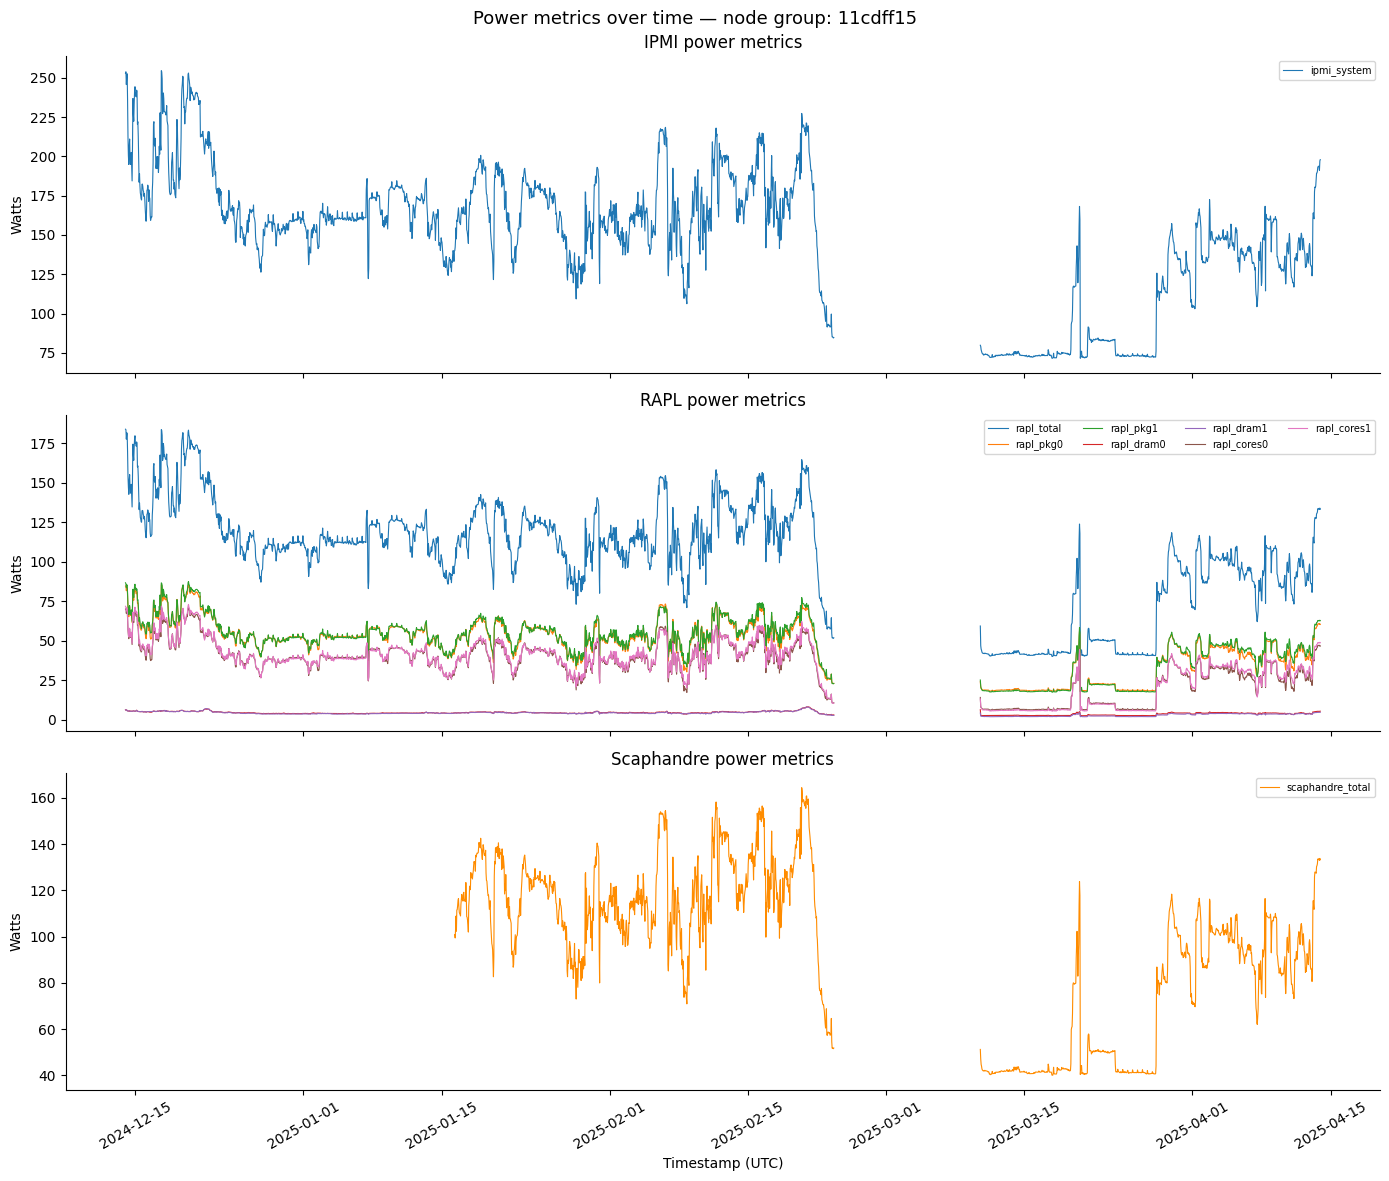

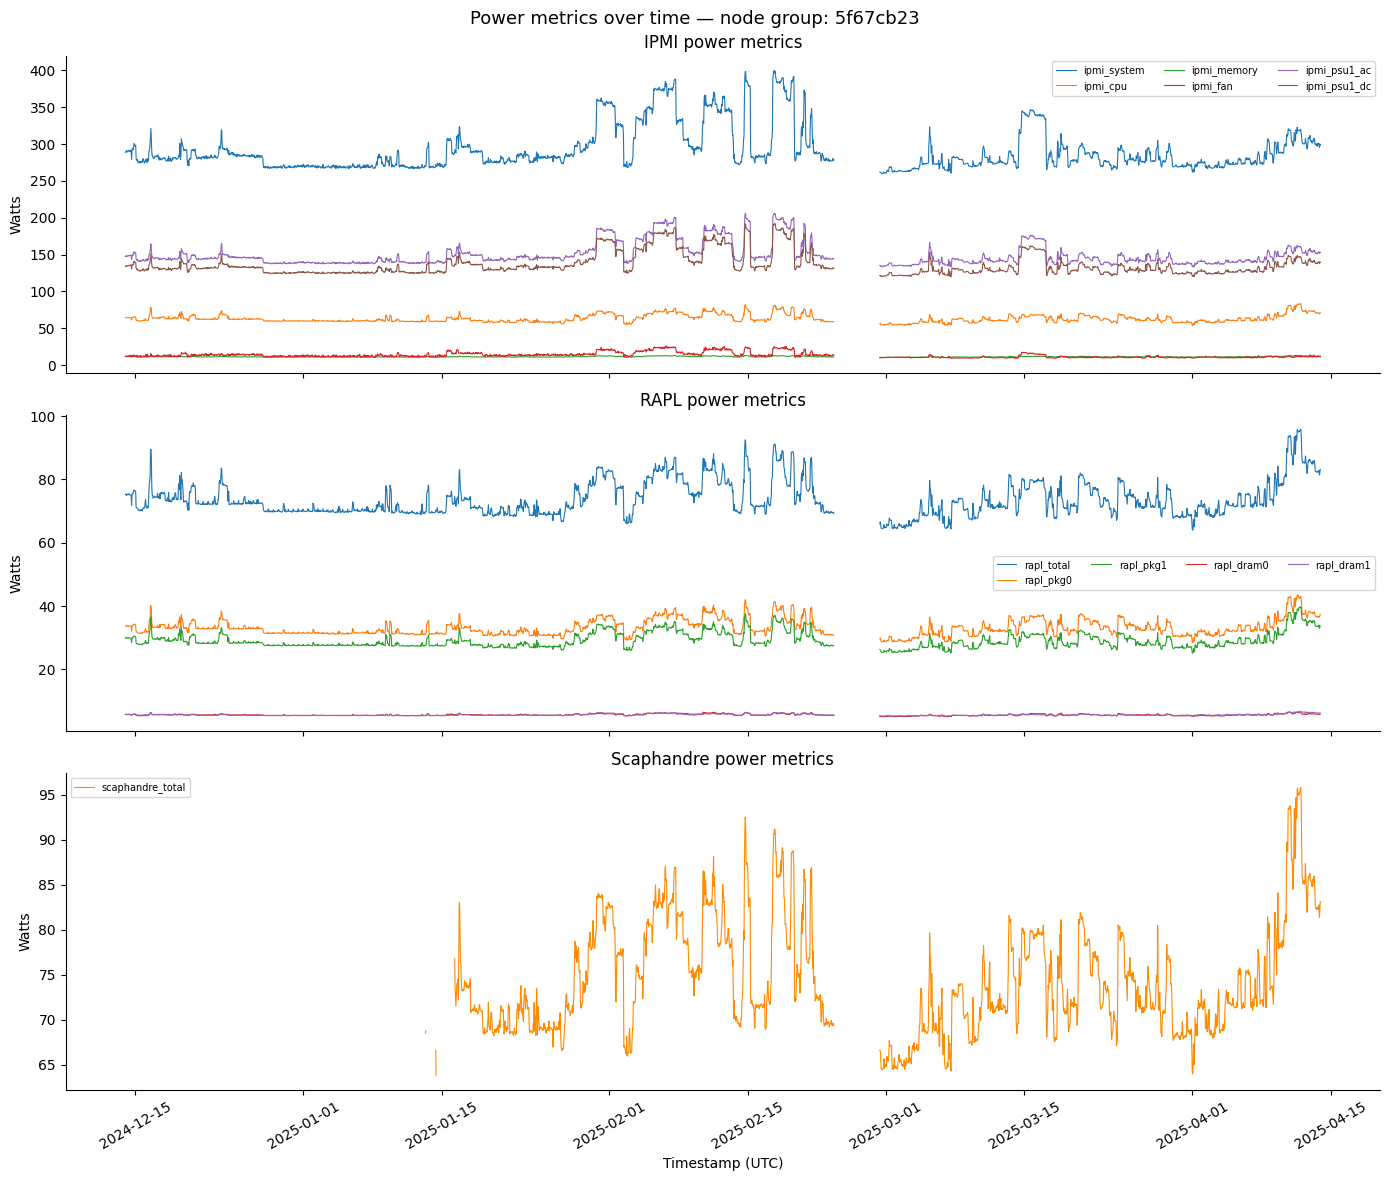

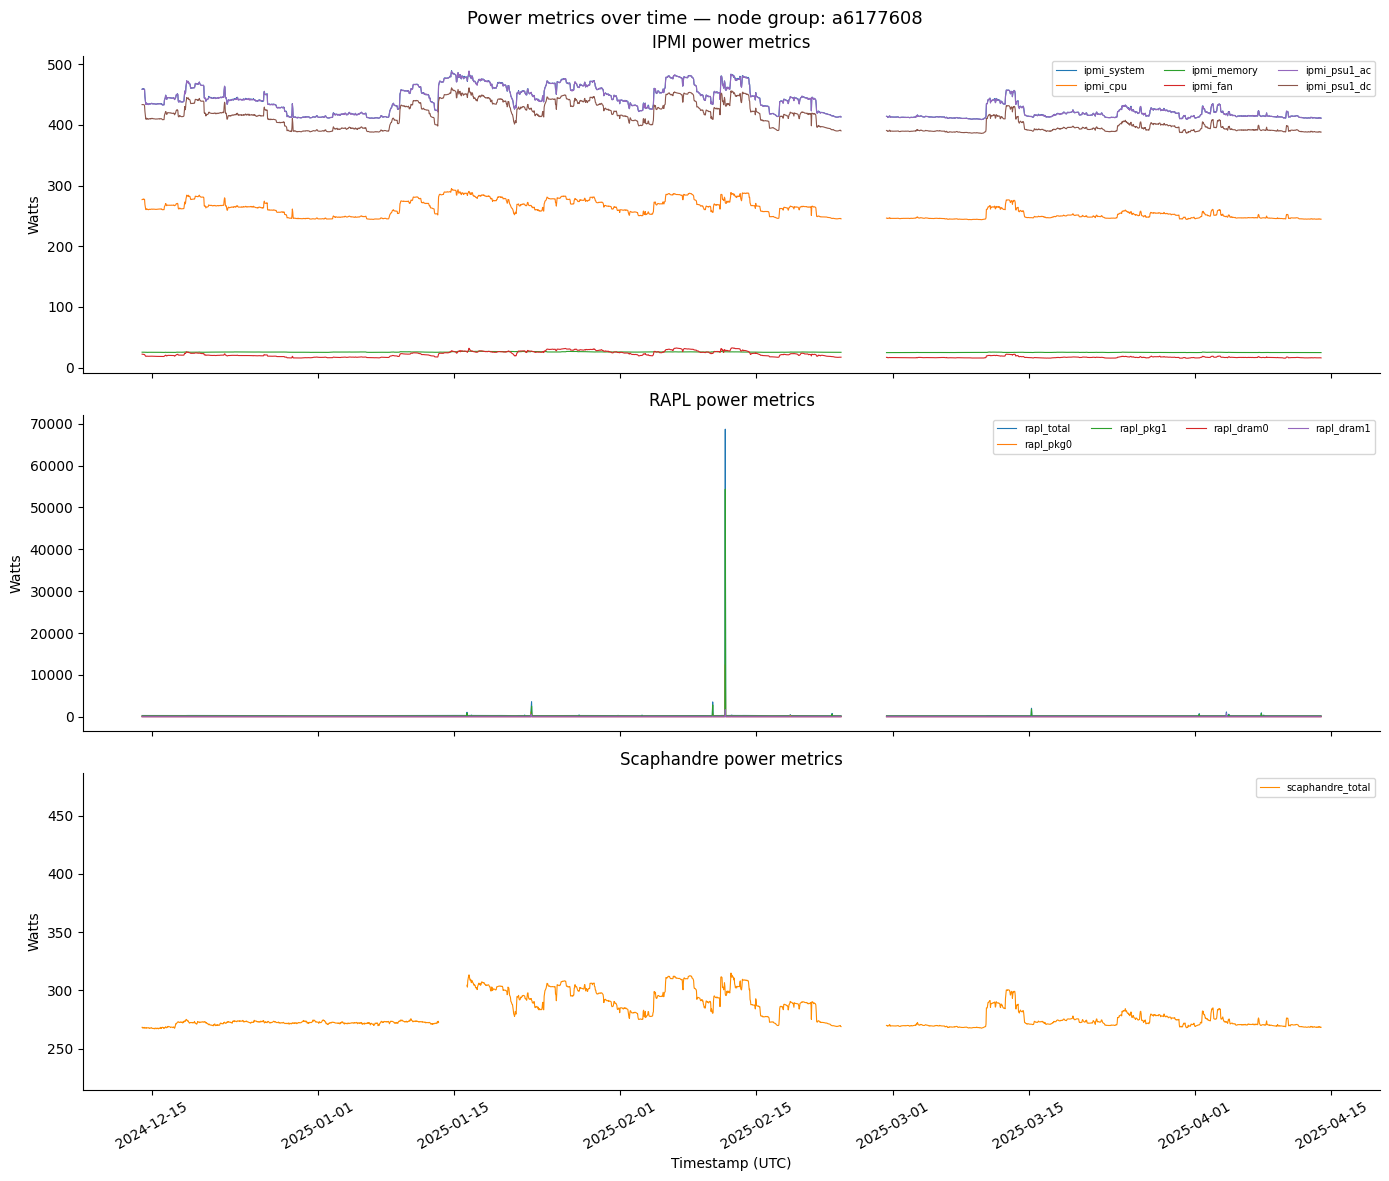

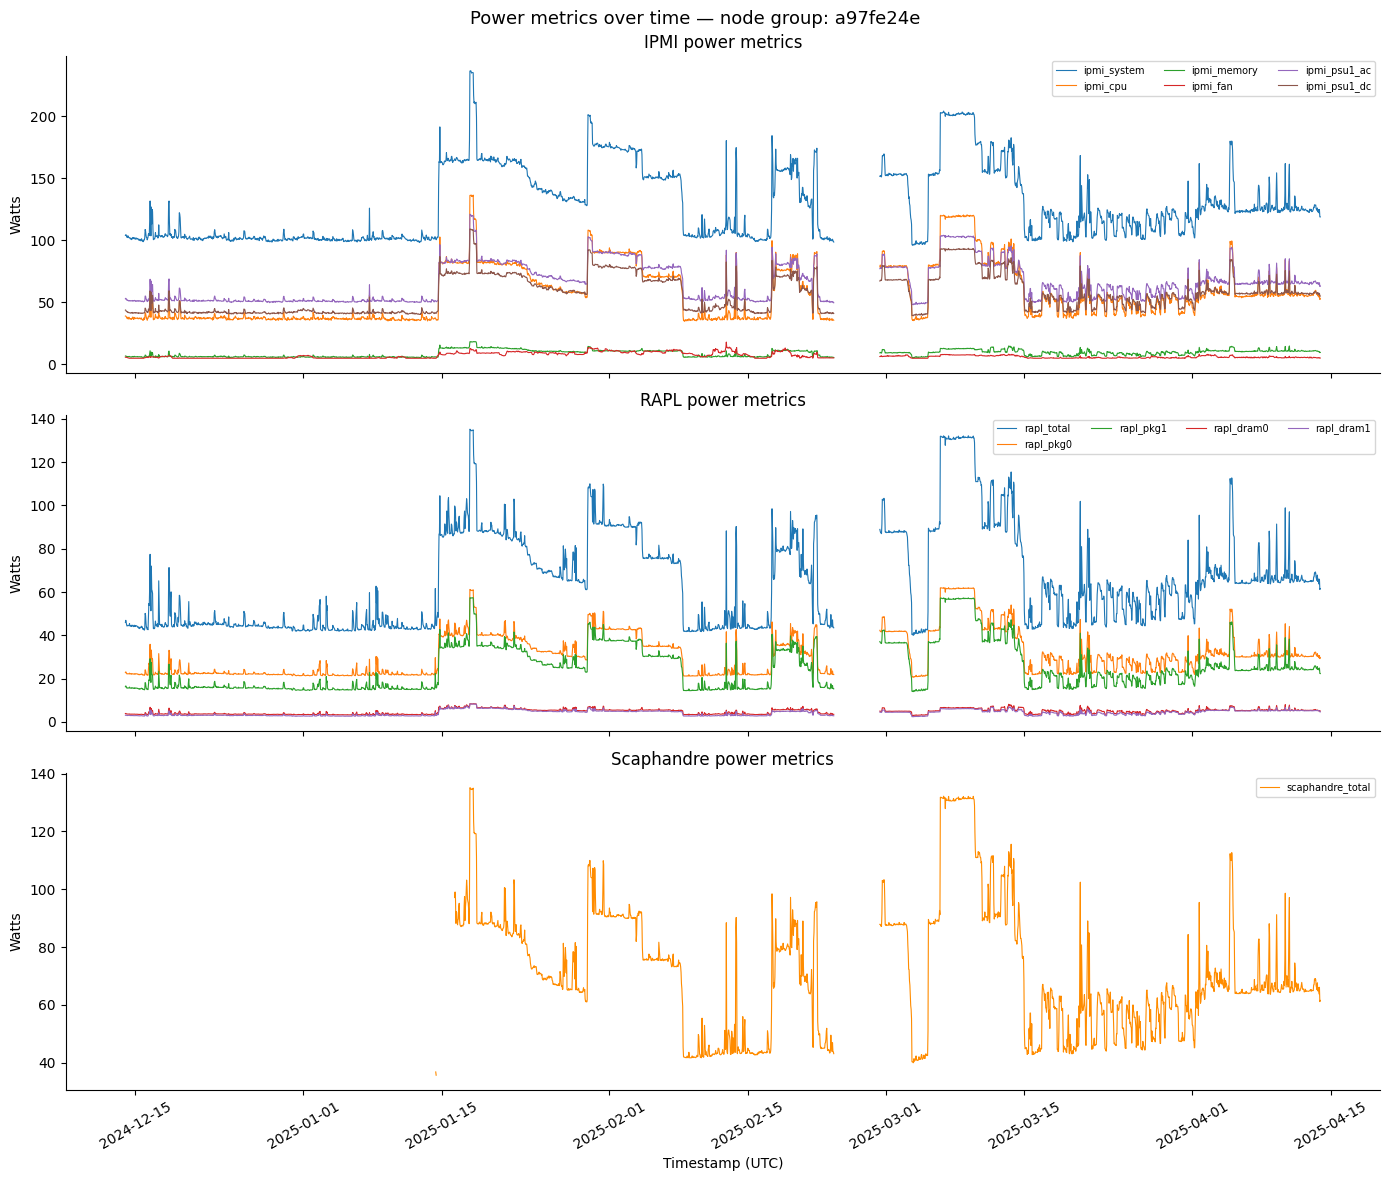

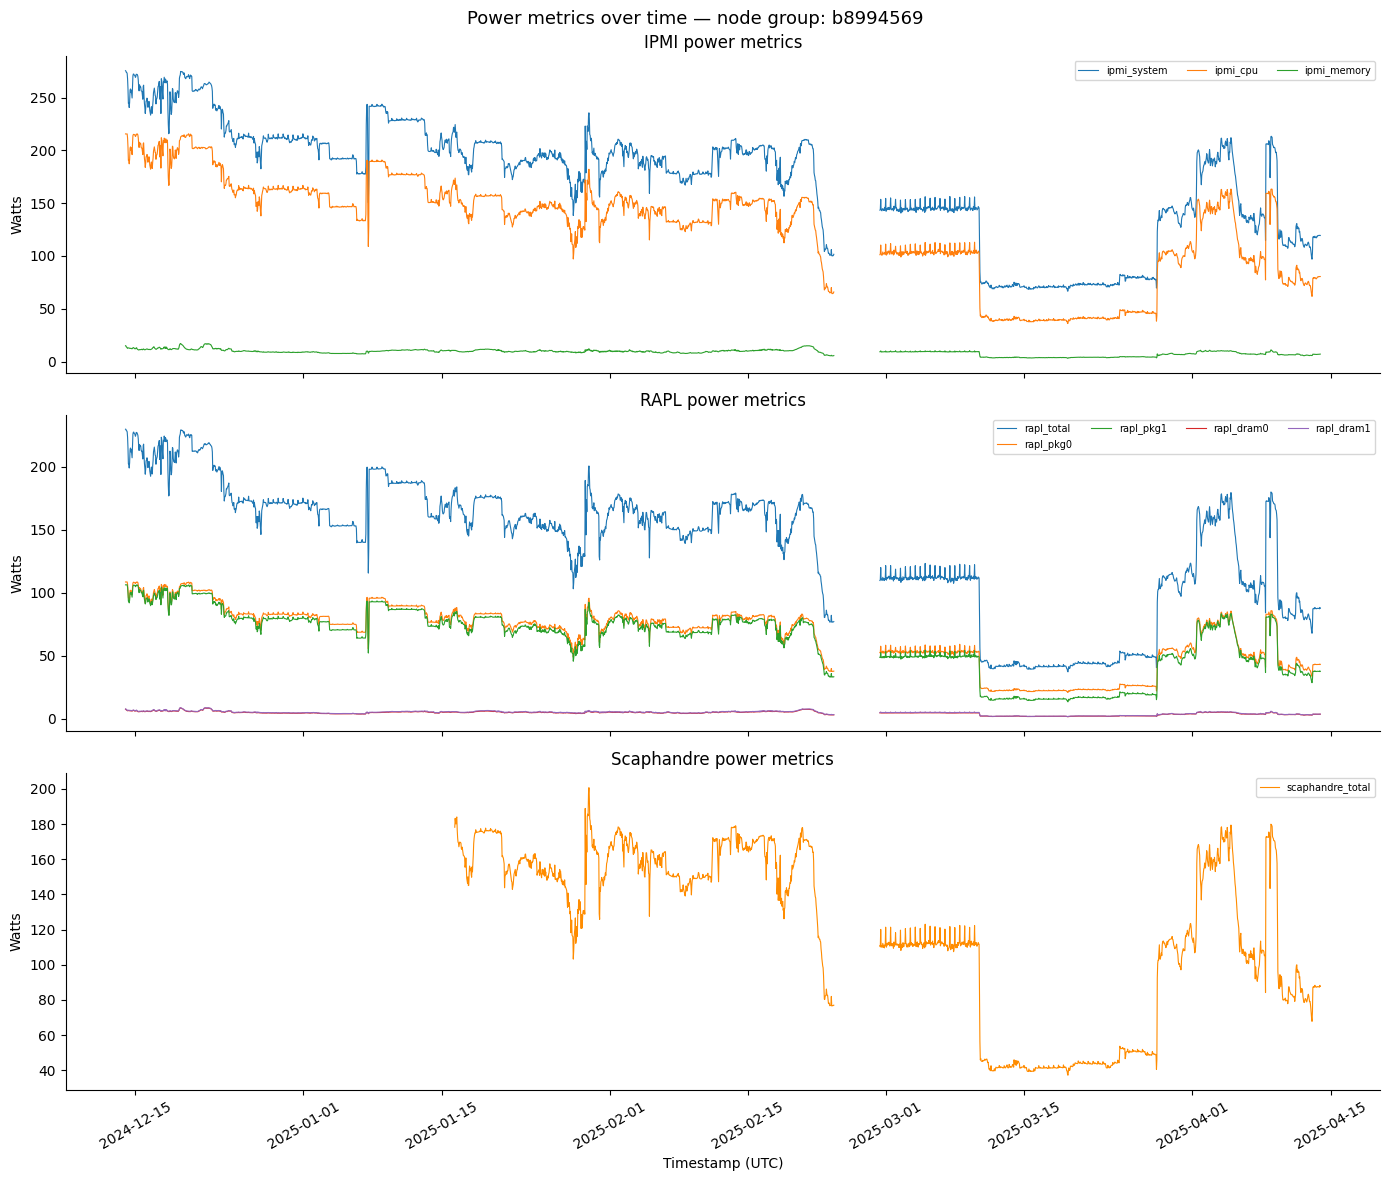

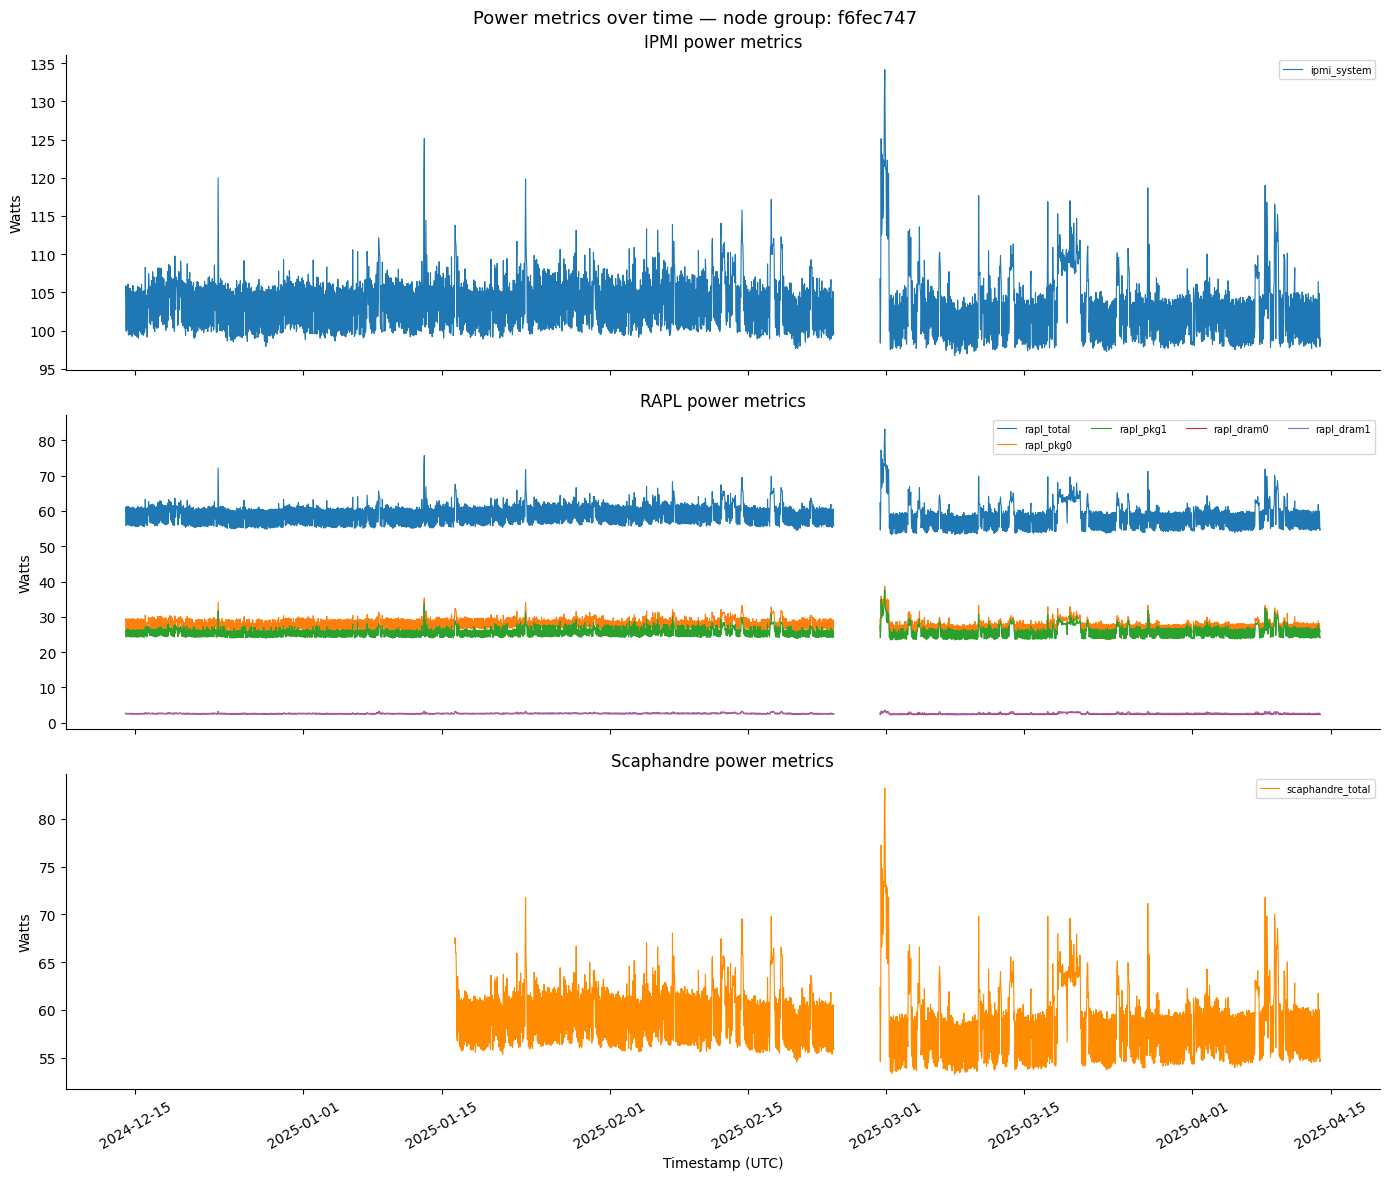

In [14]:
IPMI_PLOT  = ["ipmi_system", "ipmi_cpu", "ipmi_memory", "ipmi_fan", "ipmi_psu1_ac", "ipmi_psu1_dc"]
RAPL_PLOT  = ["rapl_total", "rapl_pkg0", "rapl_pkg1", "rapl_dram0", "rapl_dram1", "rapl_cores0", "rapl_cores1"]
SCAPH_PLOT = ["scaphandre_total"]

for group, gdf in power_hourly.groupby("node_group"):
    gdf = gdf.set_index("hour")

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f"Power metrics over time — node group: {group}", fontsize=13)

    for col in IPMI_PLOT:
        if gdf[col].notna().any():
            axes[0].plot(gdf.index, gdf[col], label=col, linewidth=0.8)
    axes[0].set_ylabel("Watts")
    axes[0].set_title("IPMI power metrics")
    axes[0].legend(fontsize=7, ncol=3)
    axes[0].spines[["top", "right"]].set_visible(False)

    for col in RAPL_PLOT:
        if gdf[col].notna().any():
            axes[1].plot(gdf.index, gdf[col], label=col, linewidth=0.8)
    axes[1].set_ylabel("Watts")
    axes[1].set_title("RAPL power metrics")
    axes[1].legend(fontsize=7, ncol=4)
    axes[1].spines[["top", "right"]].set_visible(False)

    for col in SCAPH_PLOT:
        if gdf[col].notna().any():
            axes[2].plot(gdf.index, gdf[col], label=col, color="darkorange", linewidth=0.8)
    axes[2].set_ylabel("Watts")
    axes[2].set_title("Scaphandre power metrics")
    axes[2].legend(fontsize=7)
    axes[2].spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel("Timestamp (UTC)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"plots/power_timeseries/{group}_power_timeseries.png", dpi=150, bbox_inches="tight")
    plt.show()

#### Power Histograms

In [15]:
all_nodes = con.query("SELECT * FROM nodes").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

: 

In [ ]:
#sample_group = all_nodes["node_group"].value_counts().idxmax()

ncols = 4
nrows = int(np.ceil(len(POWER_COLS) / ncols))

for sample_group in all_nodes["node_group"].unique():
    df_sample = all_nodes[all_nodes["node_group"] == sample_group]

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    for ax, col in zip(axes.flatten(), POWER_COLS):
    #if col.isna().sum() != df_sample.shape[0]:  # check if column has data
        ax.hist(df_sample[col].dropna(), bins=60, color="steelblue", edgecolor="none")
        ax.set_title(col, fontsize=9)
    for ax in axes.flatten()[len(POWER_COLS):]:
        ax.set_visible(False)
    plt.suptitle(f"Power metric distributions — group: {sample_group}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"plots/power_histograms/{sample_group}_power_histograms.png", dpi=150)
    plt.show()

In [ ]:
# these are NaN columns for the node group a6177608
#rapl_power_cores_0_watts        3775200
#rapl_power_cores_1_watts        3775200

#### Resources used over time per node group

In [35]:
CPU_USAGE_COLS      = ["cpu_usage_percent","cpu_idle_percent"]
PROC_USAGE_COLS     = ["num_processes_running","num_processes_sleeping","num_processes_stopped"]
MEM_USAGE_COLS      = ["memory_free_bytes","memory_used_bytes","memory_buffered_bytes","memory_cached_bytes"]
DISK_USAGE_COLS     = ["disk_free_bytes","disk_used_bytes","disk_reserved_bytes"]

In [34]:
# convert timestamps to datetime objects
all_nodes["timestamp"] = pd.to_datetime(all_nodes["timestamp"], utc=True)
all_nodes = all_nodes.sort_values("timestamp").reset_index(drop=True)
all_nodes.head(10)

,timestamp,node_name,node_group,cpu_usage_percent,cpu_idle_percent,cpu_nice_percent,cpu_interrupt_percent,cpu_softirq_percent,cpu_steal_percent,cpu_system_percent,...,rapl_power_cores_0_watts,rapl_power_cores_1_watts,scaphandre_power_total_watts,ipmi_cpu_power_watts,ipmi_memory_power_watts,ipmi_fan_power_watts,ipmi_psu1_ac_in_power_watts,ipmi_psu2_ac_in_power_watts,ipmi_psu1_dc_out_power_watts,ipmi_psu2_dc_out_power_watts
0,2024-12-14 00:00:00+00:00,cfc400f1,11cdff15,51.05,48.95,0.03,0.0,0.02,0.0,1.05,...,90.15,91.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-12-14 00:00:00+00:00,6fdf4d0d,b8994569,57.42,42.58,0.00,0.0,0.05,0.0,2.83,...,NaN,NaN,NaN,300.00,20.33,NaN,NaN,NaN,NaN,NaN
2,2024-12-14 00:00:00+00:00,8d5a6c7e,b8994569,80.79,19.21,0.02,0.0,0.06,0.0,1.36,...,NaN,NaN,NaN,300.00,21.83,NaN,NaN,NaN,NaN,NaN
3,2024-12-14 00:00:00+00:00,3a4828f5,5f67cb23,0.33,99.67,0.00,0.0,0.00,0.0,0.05,...,NaN,NaN,NaN,64.00,11.17,12.0,149.17,123.33,135.00,112.5
4,2024-12-14 00:00:00+00:00,a2ffa1e3,b8994569,0.02,99.98,0.00,0.0,0.00,0.0,0.01,...,NaN,NaN,NaN,31.67,2.50,NaN,NaN,NaN,NaN,NaN
5,2024-12-14 00:00:00+00:00,0861be67,a6177608,0.01,99.99,0.00,0.0,0.00,0.0,0.00,...,NaN,NaN,NaN,236.00,24.00,17.0,400.83,0.00,380.00,0.0
6,2024-12-14 00:00:00+00:00,0049db0c,a6177608,0.21,99.79,0.00,0.0,0.00,0.0,0.06,...,NaN,NaN,NaN,245.67,24.50,15.0,414.17,0.00,390.83,0.0
7,2024-12-14 00:00:00+00:00,6342c79e,5f67cb23,0.93,99.07,0.00,0.0,0.06,0.0,0.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-12-14 00:00:00+00:00,28e8b849,a6177608,0.01,99.99,0.00,0.0,0.00,0.0,0.00,...,NaN,NaN,NaN,244.00,28.00,17.0,415.83,0.00,395.00,0.0
9,2024-12-14 00:00:00+00:00,49964896,a6177608,3.46,96.54,0.01,0.0,0.00,0.0,1.04,...,NaN,NaN,NaN,260.00,23.17,17.0,435.83,0.00,413.33,0.0


In [ ]:
for group_name, group_df in all_nodes.groupby("node_group"):
 
    hourly = (
        group_df.set_index("timestamp")
                .resample("1h")
                .mean(numeric_only=True)
    )
 
    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(f"Resource metrics — {group_name}", fontsize=13)
 
    # CPU
    for col in CPU_USAGE_COLS:
        axes[0].plot(hourly.index, hourly[col], label=col)
    axes[0].set_ylabel("percent (%)")
    axes[0].set_ylim(0, 100)
    axes[0].set_title("CPU usage")
    axes[0].legend(fontsize=8)
 
    # Processes
    for col in PROC_USAGE_COLS:
        axes[1].plot(hourly.index, hourly[col], label=col)
    axes[1].set_ylabel("process count")
    axes[1].set_title("Processes")
    axes[1].legend(fontsize=8)
 
    # Memory — convert bytes to GiB
    for col in MEM_USAGE_COLS:
        axes[2].plot(hourly.index, hourly[col] / 1024**3, label=col)
    axes[2].set_ylabel("GiB")
    axes[2].set_title("Memory")
    axes[2].legend(fontsize=8)
 
    # Disk — convert bytes to TiB
    for col in DISK_USAGE_COLS:
        axes[3].plot(hourly.index, hourly[col] / 1024**4, label=col)
    axes[3].set_ylabel("TiB")
    axes[3].set_title("Disk")
    axes[3].legend(fontsize=8)
 
    for ax in axes:
        ax.grid(axis="y", linewidth=0.4, alpha=0.5)
        ax.spines[["top", "right"]].set_visible(False)
 
    axes[-1].set_xlabel("timestamp (UTC)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"plots/resource_metrics/{group_name}_resource_metrics.png", dpi=150, bbox_inches="tight")
    plt.close()

# Data Availability
### Power Metrics (NULL)

In [9]:
availability_exprs = ",\n        ".join(
    f'ROUND(100.0 * COUNT("{c}") / COUNT(*), 1) AS "{c}"'
    for c in POWER_COLS
)

coverage_df = con.query(f"""
    SELECT
        node_group,
        COUNT(*) AS total_rows,
        {availability_exprs}
    FROM nodes
    GROUP BY node_group
    ORDER BY node_group
""").df().set_index("node_group")

            ipmi_system_power_watts  ipmi_cpu_power_watts  ipmi_memory_power_watts  ipmi_fan_power_watts  ipmi_psu1_ac_in_power_watts  ipmi_psu2_ac_in_power_watts  ipmi_psu1_dc_out_power_watts  ipmi_psu2_dc_out_power_watts  rapl_power_total_watts  rapl_power_package_0_watts  rapl_power_package_1_watts  rapl_power_dram_0_watts  rapl_power_dram_1_watts  rapl_power_cores_0_watts  rapl_power_cores_1_watts  scaphandre_power_total_watts
node_group                                                                                                                                                                                                                                                                                                                                                                                                                                        
11cdff15                       88.8                   0.0                      0.0                   0.0                          

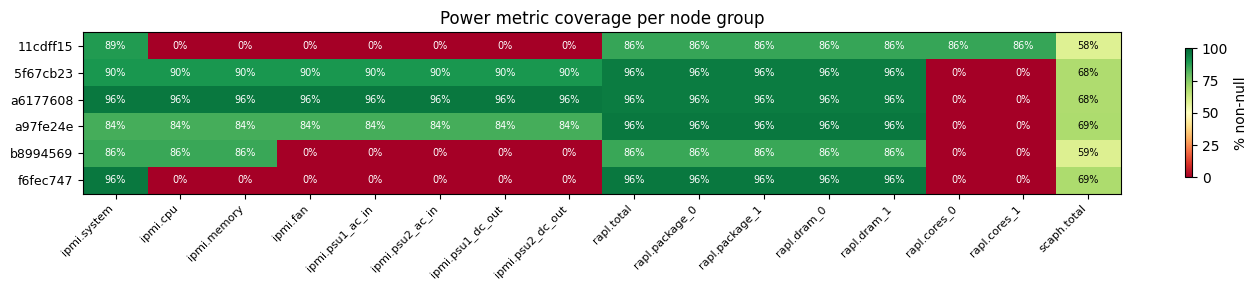

In [10]:
print(coverage_df.drop(columns="total_rows").to_string())

# Heatmap visualisation
heat_data = coverage_df.drop(columns="total_rows")

# Shorten column labels for readability
short_labels = [
    c.replace("ipmi_", "ipmi.").replace("rapl_power_", "rapl.").replace("scaphandre_power_", "scaph.")
     .replace("_watts", "").replace("_power", "")
    for c in heat_data.columns
]

fig, ax = plt.subplots(figsize=(14, 3))
im = ax.imshow(heat_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)

ax.set_xticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=9)

for i in range(len(heat_data)):
    for j in range(len(heat_data.columns)):
        val = heat_data.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center",
                fontsize=7, color="black" if 20 < val < 80 else "white")

plt.colorbar(im, ax=ax, label="% non-null", shrink=0.8)
ax.set_title("Power metric coverage per node group", fontsize=12)
plt.tight_layout()
plt.savefig("plots/power_metric_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlations
Resource usage vs. power consumption per node group

In [13]:
CORR_POWER = [
    "ipmi_system_power_watts", "ipmi_cpu_power_watts",
    "rapl_power_total_watts", "scaphandre_power_total_watts"
]
CORR_RESOURCE = [
    "cpu_usage_percent", "cpu_system_percent", "cpu_user_percent",
    "memory_used_bytes", "disk_used_bytes",
    "network_bw_rx_b/s", "network_bw_tx_b/s",
    "num_processes_running"
]

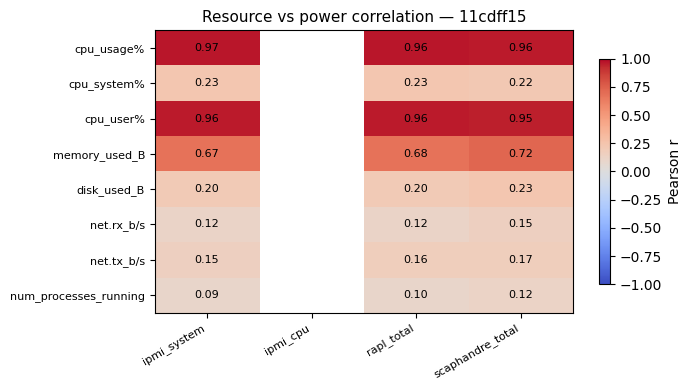

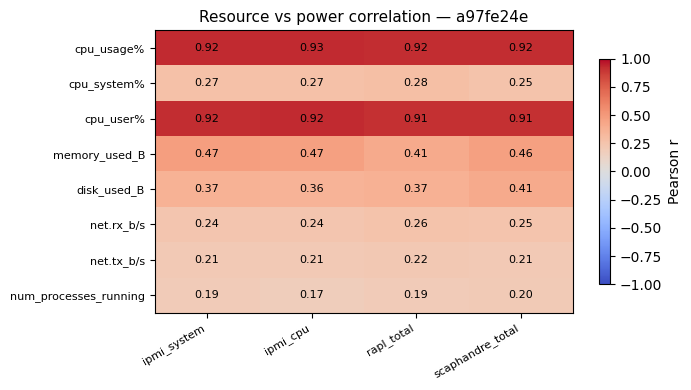

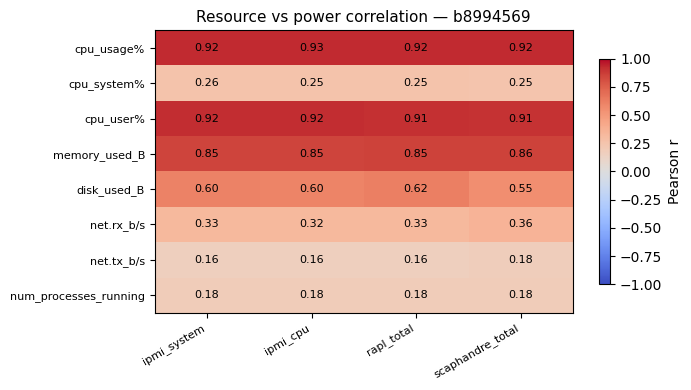

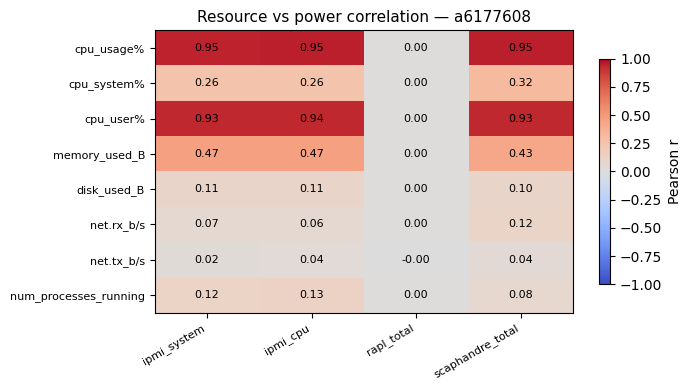

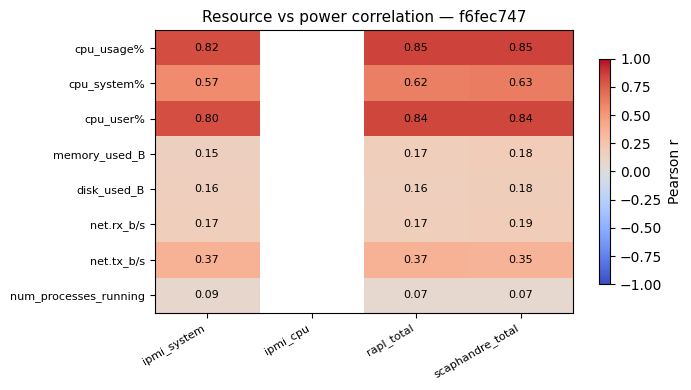

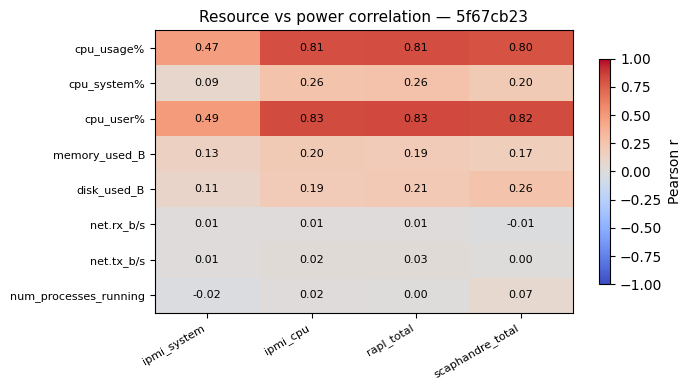

In [18]:
corr_exprs = ",\n        ".join(
    f'CORR(TRY_CAST("{r}" AS DOUBLE), TRY_CAST("{p}" AS DOUBLE)) AS "corr__{r}__{p}"'
    for r in CORR_RESOURCE
    for p in CORR_POWER
)
corr_raw = con.query(f"""
    SELECT
        node_group,
        {corr_exprs}
    FROM nodes
    GROUP BY node_group
""").df()

for _, row in corr_raw.iterrows():
    group = row["node_group"]

    # Reshape the flat row into a (resource x power) matrix
    matrix = pd.DataFrame(index=CORR_RESOURCE, columns=CORR_POWER, dtype=float)
    for r in CORR_RESOURCE:
        for p in CORR_POWER:
            matrix.loc[r, p] = row.get(f"corr__{r}__{p}", float("nan"))

    # Skip groups where all correlations are NaN
    if matrix.isna().all(axis=None):
        print(f"[{group}] no overlapping non-null data — skipping")
        continue

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(matrix.values.astype(float), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(range(len(CORR_POWER)))
    ax.set_xticklabels(
        [c.replace("_watts", "").replace("_power", "") for c in CORR_POWER],
        rotation=30, ha="right", fontsize=8
    )
    ax.set_yticks(range(len(CORR_RESOURCE)))
    ax.set_yticklabels(
        [c.replace("_percent", "%").replace("_bytes", "_B").replace("network_bw_", "net.") for c in CORR_RESOURCE],
        fontsize=8
    )

    for i in range(len(CORR_RESOURCE)):
        for j in range(len(CORR_POWER)):
            val = matrix.values[i, j]
            if not pd.isna(val):
                ax.text(j, i, f"{float(val):.2f}", ha="center", va="center", fontsize=8)

    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)
    ax.set_title(f"Resource vs power correlation — {group}", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"plots/correlations/{group}_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

# Merging tables